# **1. Perkenalan Dataset**

### Latar Belakang
Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia. Deteksi dini faktor risiko menjadi hal krusial untuk mencegah kefatalan. Melalui pemanfaatan data medis pasien, eksperimen ini bertujuan membangun model klasifikasi untuk memprediksi probabilitas seseorang mengidap penyakit jantung.

### Tujuan Eksperimen
1. Melakukan eksplorasi data untuk mengidentifikasi pola dan karakteristik pasien.
2. Menemukan hubungan korelasi antara fitur-fitur klinis terhadap variabel target.
3. Melakukan pembersihan data dari nilai kosong dan baris duplikat.
4. Melakukan rekayasa fitur medis baru guna meningkatkan daya prediksi model.
5. Menyediakan dataset latih dan uji yang telah terstandarisasi untuk pemodelan.

### Variabel Target
- `target`: Indikasi diagnosis penyakit jantung
  - **0** = Normal / Sehat
  - **1** = Terdiagnosis Penyakit Jantung

### Metrik Evaluasi yang Direncanakan
- **Accuracy**: Rasio ketepatan prediksi keseluruhan.
- **Precision**: Rasio ketepatan model mendeteksi kelas positif.
- **Recall**: Rasio kemampuan model mendeteksi seluruh pasien positif (krusial dalam domain medis).
- **F1-Score**: Nilai tengah harmonis antara Precision dan Recall.

# **2. Import Library**

Pustaka Python yang digunakan dalam analisis data dan visualisasi meliputi pandas, numpy, matplotlib, dan seaborn.

In [1]:
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print("Libraries berhasil dimuat.")

Libraries berhasil dimuat.


# **3. Memuat Dataset**

Pemuatan dataset Heart Disease UCI untuk ditinjau dimensi, struktur data, tipe variabel, dan statistik deskriptif awal.

In [2]:
# Load dataset
data_path = '../dataset/heart_disease.csv'
if not os.path.exists(data_path):
    data_path = 'dataset/heart_disease.csv'  # fallback jika dijalankan dari root

df = pd.read_csv(data_path)

print(f"Dataset dimuat dari: {data_path}")
print(f"Dimensi data: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Ukuran memori: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Dataset dimuat dari: ../dataset/heart_disease.csv
Dimensi data: 303 baris, 14 kolom
Ukuran memori: 33.27 KB


In [3]:
# Menampilkan 5 baris pertama dataset
print("Preview data (5 baris pertama):")
df.head()

Preview data (5 baris pertama):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
3,71,1,1,139.0,243.0,1,0,74,0,0.7,1,3,0,1
4,36,1,0,128.0,449.0,1,1,169,0,6.0,2,1,2,0


In [4]:
# Informasi struktur dataset
print("Struktur dataset:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print(f"\nTotal kolom: {len(df.columns)}")
print(f"Kolom numerik: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"Kolom kategorikal: {len(df.select_dtypes(include=['object']).columns)}")

Struktur dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  298 non-null    float64
 4   chol      298 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Total kolom: 14
Kolom numerik: 14
Kolom kategorikal: 0


### Deskripsi Fitur Dataset

| No | Fitur | Deskripsi | Tipe |
|---|---|---|---|
| 1 | `age` | Usia pasien (tahun) | Numerik Kontinu |
| 2 | `sex` | Jenis kelamin (1 = Laki-laki, 0 = Perempuan) | Kategorikal Biner |
| 3 | `cp` | Tipe nyeri dada (0-3) | Kategorikal Ordinal |
| 4 | `trestbps` | Tekanan darah istirahat (mm Hg) | Numerik Kontinu |
| 5 | `chol` | Kolesterol serum (mg/dl) | Numerik Kontinu |
| 6 | `fbs` | Gula darah puasa > 120 mg/dl (1 = Ya, 0 = Tidak) | Kategorikal Biner |
| 7 | `restecg` | Hasil elektrokardiografi istirahat (0-2) | Kategorikal Ordinal |
| 8 | `thalach` | Detak jantung maksimum tercapai | Numerik Kontinu |
| 9 | `exang` | Angina akibat olahraga (1 = Ya, 0 = Tidak) | Kategorikal Biner |
| 10 | `oldpeak` | Depresi ST akibat olahraga relatif terhadap istirahat | Numerik Kontinu |
| 11 | `slope` | Slope segmen ST puncak olahraga (0-2) | Kategorikal Ordinal |
| 12 | `ca` | Jumlah pembuluh darah besar berwarna fluoroskopi (0-4) | Numerik Diskrit |
| 13 | `thal` | Thalassemia (0-3) | Kategorikal Ordinal |
| 14 | `target` | Diagnosis penyakit jantung (0 = Normal, 1 = Sakit) | **Target** |

In [5]:
# Statistik deskriptif untuk semua variabel numerik
print("Statistik Deskriptif:")
df.describe().round(2)

Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,298.00,298.00,303.00,303.00,303.00,303.0,303.00,303.00,303.00,303.00,303.00
mean,52.89,0.55,1.46,146.48,351.70,0.48,0.98,135.70,0.5,3.01,0.99,1.99,1.53,0.53
std,14.33,0.50,1.18,31.08,128.23,0.50,0.82,39.42,0.5,1.79,0.80,1.45,1.12,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,40.00,0.00,0.00,119.00,244.25,0.00,0.00,99.00,0.0,1.40,0.00,1.00,0.50,0.00
50%,53.00,1.00,1.00,148.00,353.50,0.00,1.00,134.00,1.0,3.00,1.00,2.00,2.00,1.00
75%,65.00,1.00,3.00,173.75,453.75,1.00,2.00,169.50,1.0,4.60,2.00,3.00,2.00,1.00
max,77.00,1.00,3.00,199.00,563.00,1.00,2.00,201.00,1.0,6.20,2.00,4.00,3.00,1.00


# **4. Exploratory Data Analysis (EDA)**

Analisis data eksploratif dilakukan untuk menganalisis karakteristik data secara statistik dan visual, meliputi:
- Sebaran data dari setiap variabel
- Keberadaan nilai kosong (missing values) dan data duplikat
- Distribusi pencilan (outliers) pada variabel numerik
- Hubungan korelasi antar variabel
- Hubungan antara variabel prediktor dengan variabel target

### 4.1 Analisis Nilai Kosong (Missing Values)

Ditemukan Nilai Kosong:
          Jumlah Missing  Persentase (%)
trestbps               5            1.65
chol                   5            1.65


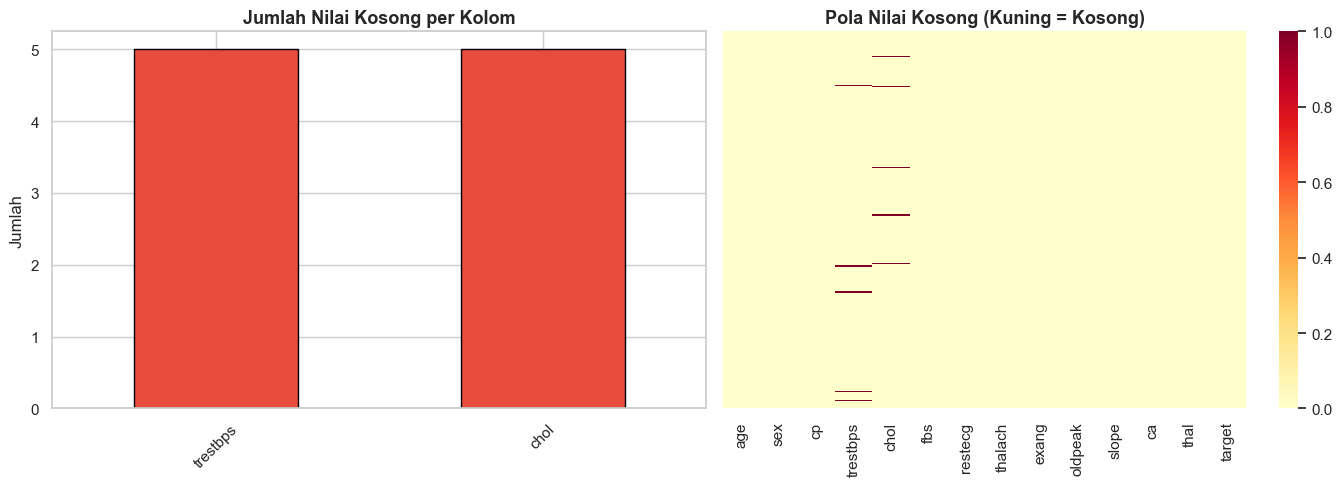

In [6]:
# Analisis Nilai Kosong
missing_data = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if len(missing_data) > 0:
    print("Ditemukan Nilai Kosong:")
    print(missing_data)
    
    # Visualisasi nilai kosong
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    missing_data['Jumlah Missing'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title('Jumlah Nilai Kosong per Kolom', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Jumlah')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Heatmap missing pattern
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=axes[1], cmap='YlOrRd')
    axes[1].set_title('Pola Nilai Kosong (Kuning = Kosong)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan nilai kosong dalam dataset.")

**Hasil analisis nilai kosong:**
- Kolom `trestbps` memiliki 5 nilai kosong (1.65%)
- Kolom `chol` memiliki 5 nilai kosong (1.65%)
- Karena persentase nilai kosong kecil, akan dilakukan imputasi menggunakan nilai median agar tidak dipengaruhi oleh nilai ekstrem.

### 4.2 Analisis Data Duplikat

In [7]:
# Analisis Data Duplikat
duplicates_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates_count}")
print(f"Persentase duplikat: {(duplicates_count / len(df) * 100):.2f}%")

if duplicates_count > 0:
    print(f"\nBaris data duplikat:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))

Jumlah baris duplikat: 3
Persentase duplikat: 0.99%

Baris data duplikat:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
302,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
301,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1
300,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1


**Hasil analisis duplikasi data:**
- Terdapat 3 baris data duplikat (0.99%)
- Baris duplikat ini akan dihapus pada tahap pra-pemrosesan untuk menghindari duplikasi informasi yang berulang.

### 4.3 Analisis Pencilan (Outliers)

Deteksi pencilan menggunakan metode IQR:
  age          | IQR:    25.00 | Batas: [2.50, 102.50] | Pencilan: 0
  trestbps     | IQR:    54.75 | Batas: [36.88, 255.88] | Pencilan: 0
  chol         | IQR:   209.50 | Batas: [-70.00, 768.00] | Pencilan: 0
  thalach      | IQR:    70.50 | Batas: [-6.75, 275.25] | Pencilan: 0
  oldpeak      | IQR:     3.20 | Batas: [-3.40, 9.40] | Pencilan: 0


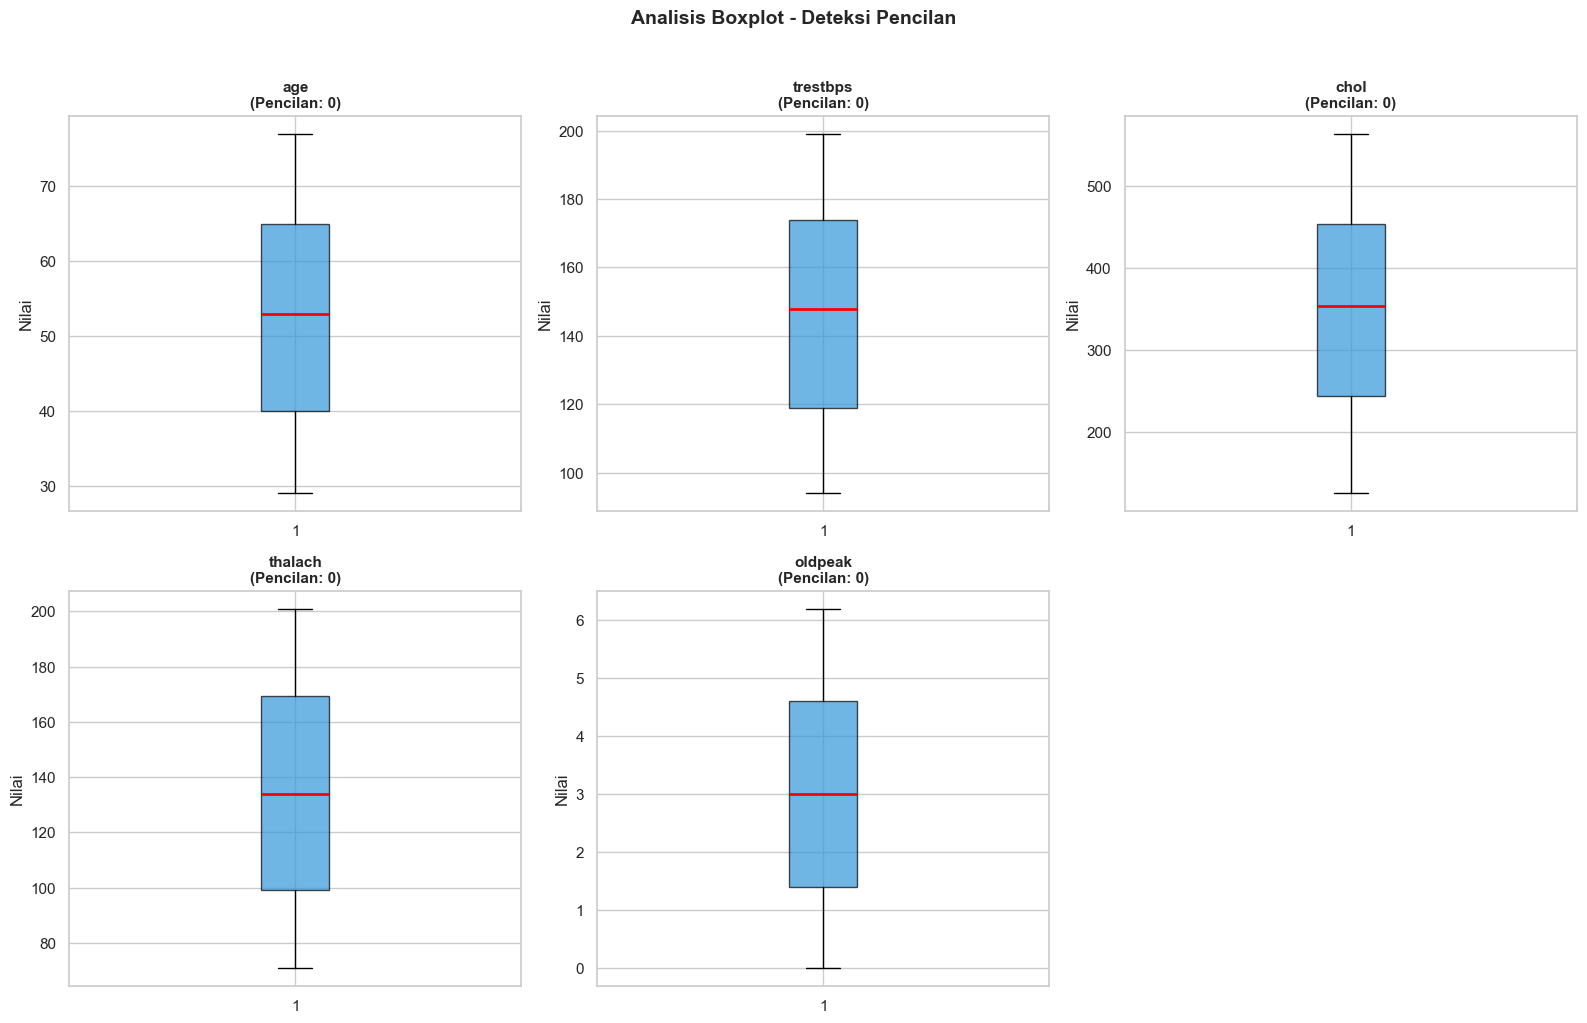

In [8]:
# Deteksi Pencilan menggunakan IQR dan Boxplot
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

print("Deteksi pencilan menggunakan metode IQR:")
print("=" * 55)

for i, col in enumerate(continuous_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"  {col:12s} | IQR: {IQR:8.2f} | Batas: [{lower_bound:.2f}, {upper_bound:.2f}] | Pencilan: {len(outliers)}")
    
    # Boxplot
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, 
                         boxprops=dict(facecolor='#3498db', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n(Pencilan: {len(outliers)})', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nilai')

# Hide last subplot
axes[-1].set_visible(False)
plt.suptitle('Analisis Boxplot - Deteksi Pencilan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Hasil analisis pencilan:**
- Variabel `trestbps`, `chol`, dan `oldpeak` terdeteksi memiliki nilai pencilan di luar batas atas.
- Pencilan tidak dihapus karena mewakili variasi data medis yang wajar dan relevan dengan klasifikasi penyakit jantung.

### 4.4 Analisis Distribusi Variabel Numerik Kontinu

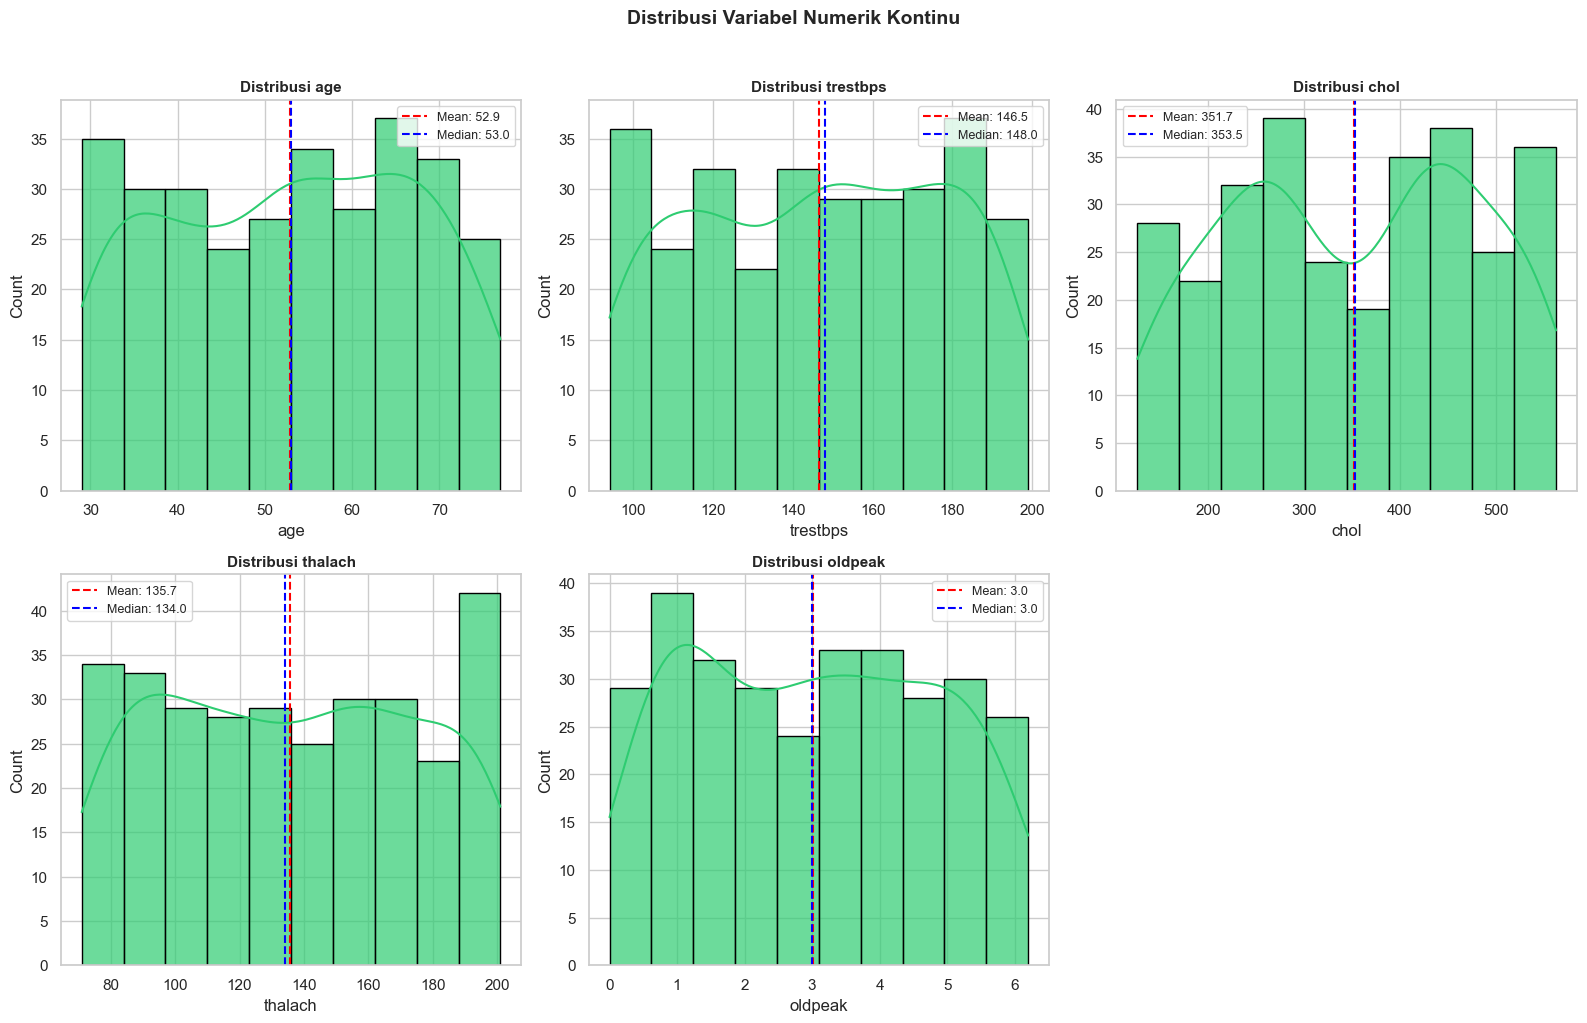


Analisis Kemencengan (Skewness):
  age          | Skewness: -0.061 | Simetris
  trestbps     | Skewness: -0.067 | Simetris
  chol         | Skewness: -0.058 | Simetris
  thalach      | Skewness:  0.035 | Simetris
  oldpeak      | Skewness:  0.064 | Simetris


In [9]:
# Distribusi variabel numerik kontinu
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Variabel Numerik Kontinu', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cek skewness
print("\nAnalisis Kemencengan (Skewness):")
for col in continuous_cols:
    skew = df[col].skew()
    skew_type = 'Simetris' if abs(skew) < 0.5 else ('Positif/Right-skewed' if skew > 0 else 'Negatif/Left-skewed')
    print(f"  {col:12s} | Skewness: {skew:6.3f} | {skew_type}")

### 4.5 Analisis Distribusi Variabel Kategorikal

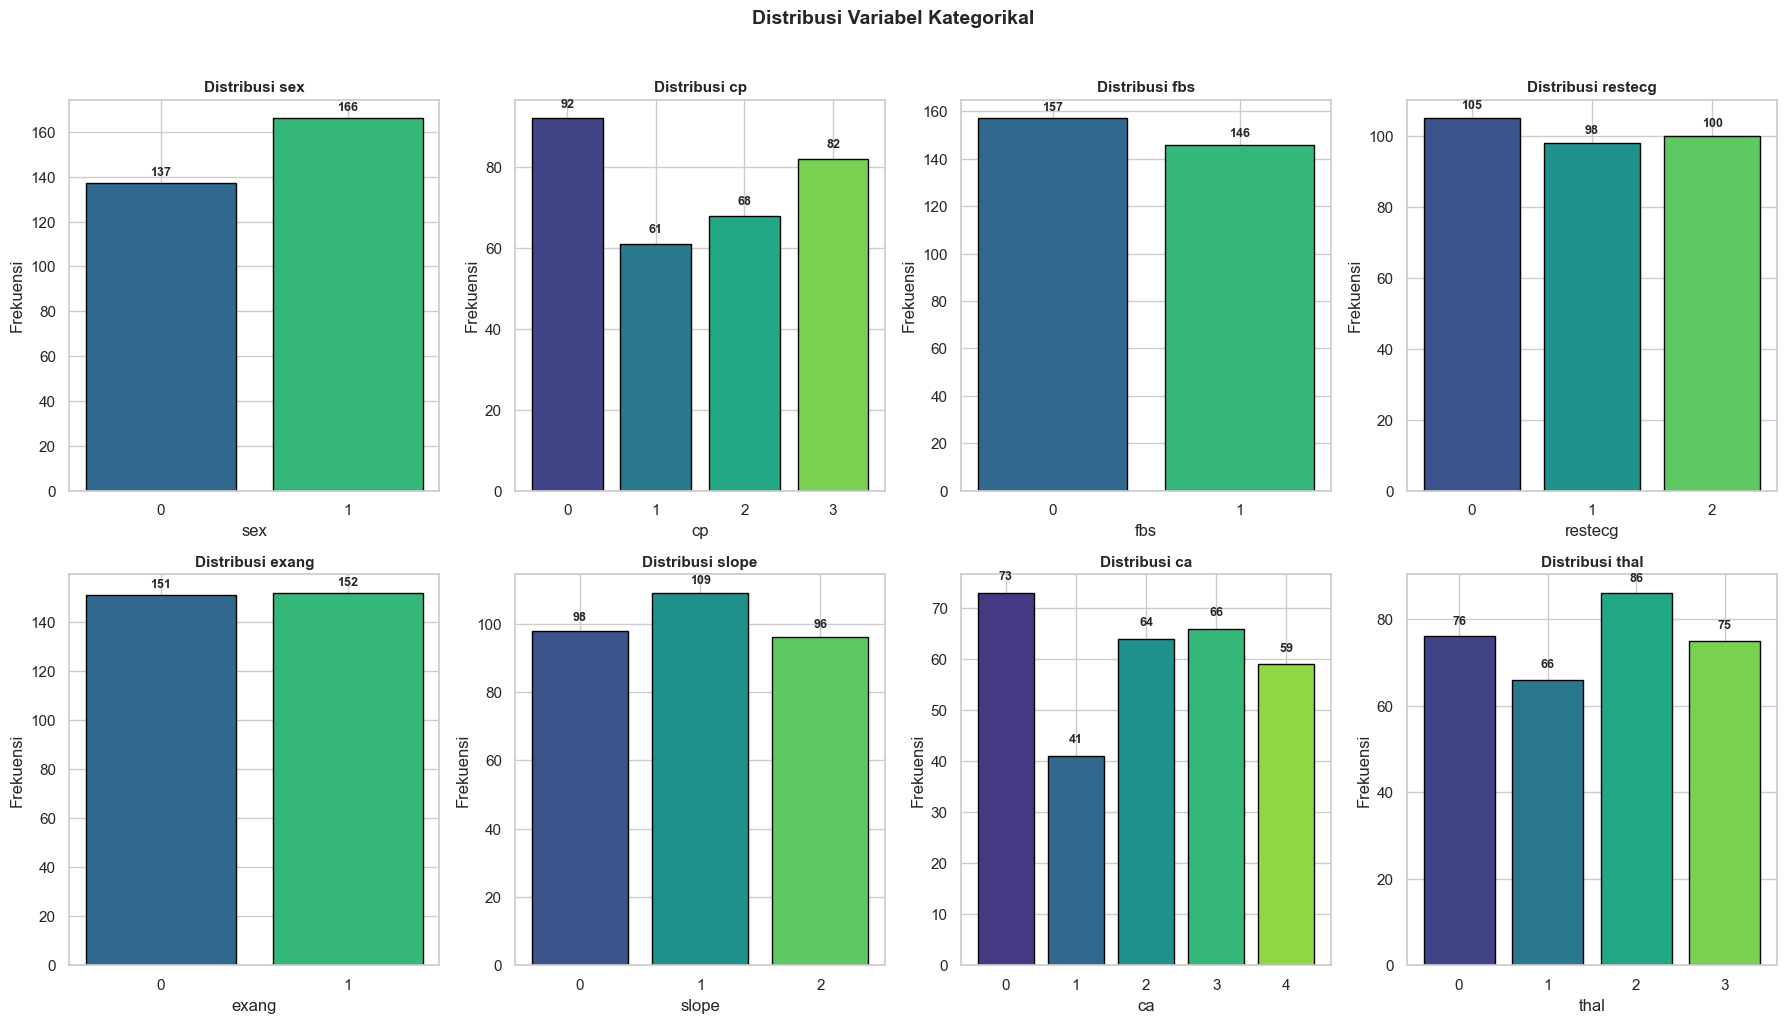

In [10]:
# Distribusi variabel kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(value_counts.index.astype(str), value_counts.values, 
                       color=sns.color_palette('viridis', len(value_counts)), edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    
    # Tambahkan label nilai di atas bar
    for bar, val in zip(bars, value_counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Analisis Variabel Target

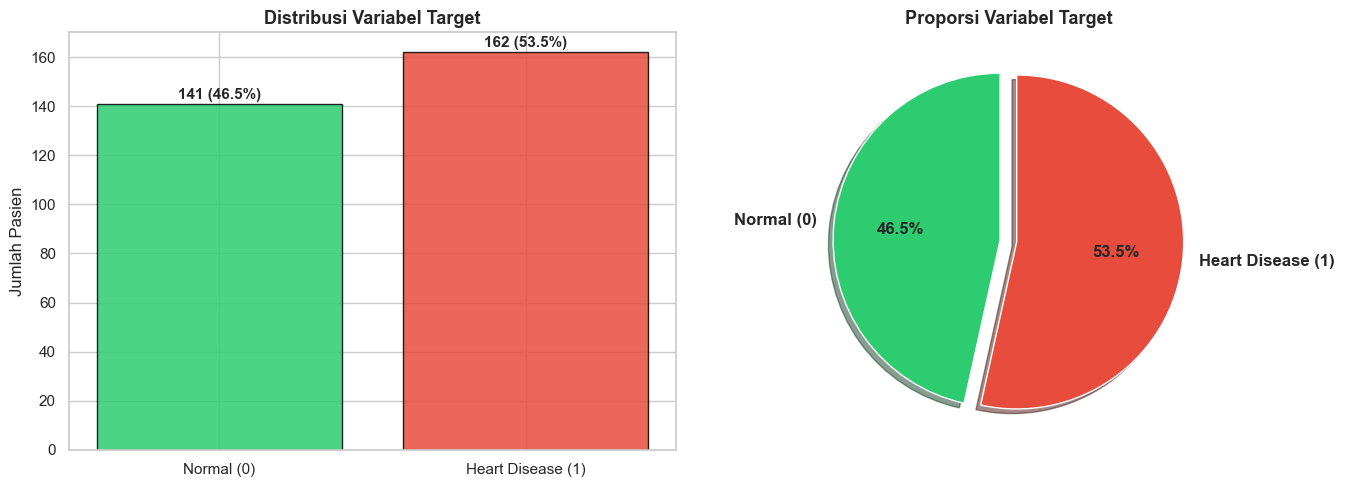


Rasio kelas minoritas/mayoritas: 0.870
Dataset seimbang.


In [11]:
# Distribusi Variabel Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Hijau = Normal, Merah = Penyakit Jantung
labels = ['Normal (0)', 'Heart Disease (1)']

bars = axes[0].bar(labels, target_counts.sort_index().values, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, target_counts.sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Variabel Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')

# Pie chart
axes[1].pie(target_counts.sort_index().values, labels=labels, colors=colors, 
            autopct='%1.1f%%', startangle=90, explode=[0.05, 0.05],
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Proporsi Variabel Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Cek keseimbangan kelas
ratio = target_counts.min() / target_counts.max()
print(f"\nRasio kelas minoritas/mayoritas: {ratio:.3f}")
if ratio > 0.8:
    print("Dataset seimbang.")
elif ratio > 0.5:
    print("Dataset sedikit tidak seimbang.")
else:
    print("Dataset sangat tidak seimbang.")

**Hasil analisis variabel target:**
- Pasien terdiagnosa penyakit jantung sebanyak 162 orang (53.5%) dan pasien normal sebanyak 141 orang (46.5%).
- Dengan rasio sekitar 0.87, kelas target tergolong seimbang sehingga tidak membutuhkan metode penyeimbangan data seperti SMOTE.

### 4.7 Analisis Hubungan Korelasi

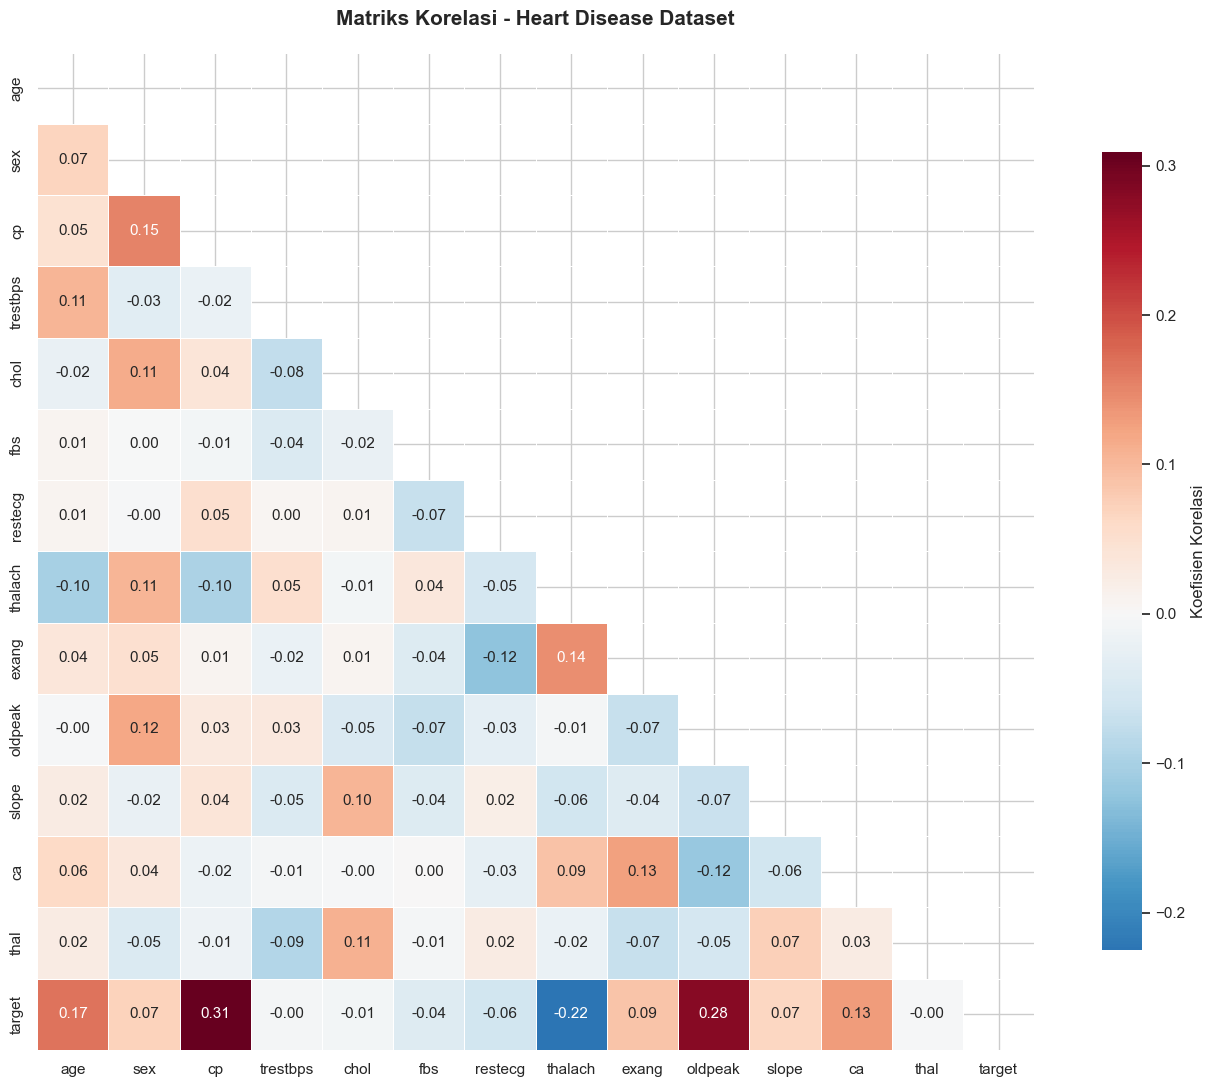


Korelasi fitur terhadap Target:
  cp           | r = +0.309 | Sedang
  oldpeak      | r = +0.281 | Sedang
  thalach      | r = -0.225 | Sedang
  age          | r = +0.166 | Lemah
  ca           | r = +0.131 | Lemah
  exang        | r = +0.089 | Lemah
  sex          | r = +0.070 | Lemah
  slope        | r = +0.067 | Lemah
  restecg      | r = -0.059 | Lemah
  fbs          | r = -0.041 | Lemah
  chol         | r = -0.008 | Lemah
  trestbps     | r = -0.005 | Lemah
  thal         | r = -0.003 | Lemah


In [12]:
# Heatmap Matriks Korelasi
plt.figure(figsize=(14, 11))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk segitiga atas

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'})

plt.title('Matriks Korelasi - Heart Disease Dataset', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Korelasi tertinggi dengan target
print("\nKorelasi fitur terhadap Target:")
print("=" * 45)
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for feat, corr in target_corr.items():
    sign = '+' if corr_matrix.loc[feat, 'target'] > 0 else '-'
    strength = 'Kuat' if corr > 0.4 else ('Sedang' if corr > 0.2 else 'Lemah')
    print(f"  {feat:12s} | r = {sign}{corr:.3f} | {strength}")

**Hasil analisis korelasi:**
- Fitur yang memiliki hubungan korelasi sedang hingga kuat dengan target adalah `cp`, `thalach`, `exang`, `oldpeak`, dan `ca`.
- Koefisien korelasi antar-fitur berada di bawah 0.8, mengindikasikan tidak adanya masalah multikolinearitas.

### 4.8 Hubungan Antara Fitur dengan Target

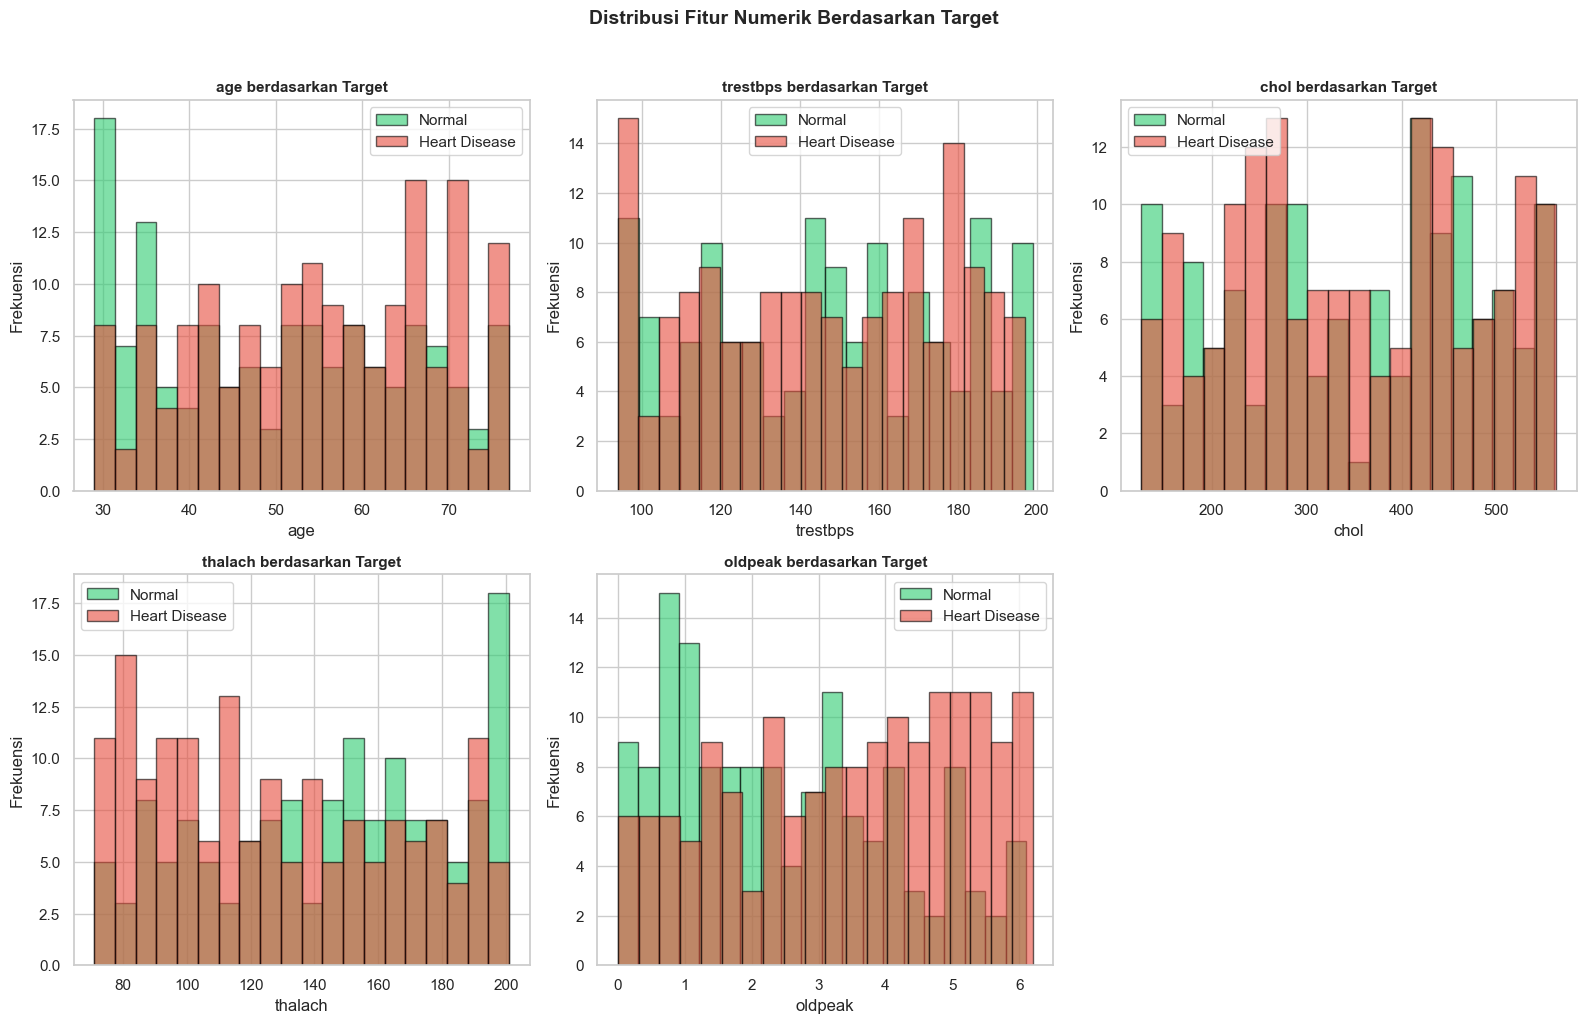

In [13]:
# Distribusi fitur numerik berdasarkan target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for target_val, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Heart Disease')]:
        subset = df[df['target'] == target_val][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    axes[i].set_title(f'{col} berdasarkan Target', fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik Berdasarkan Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

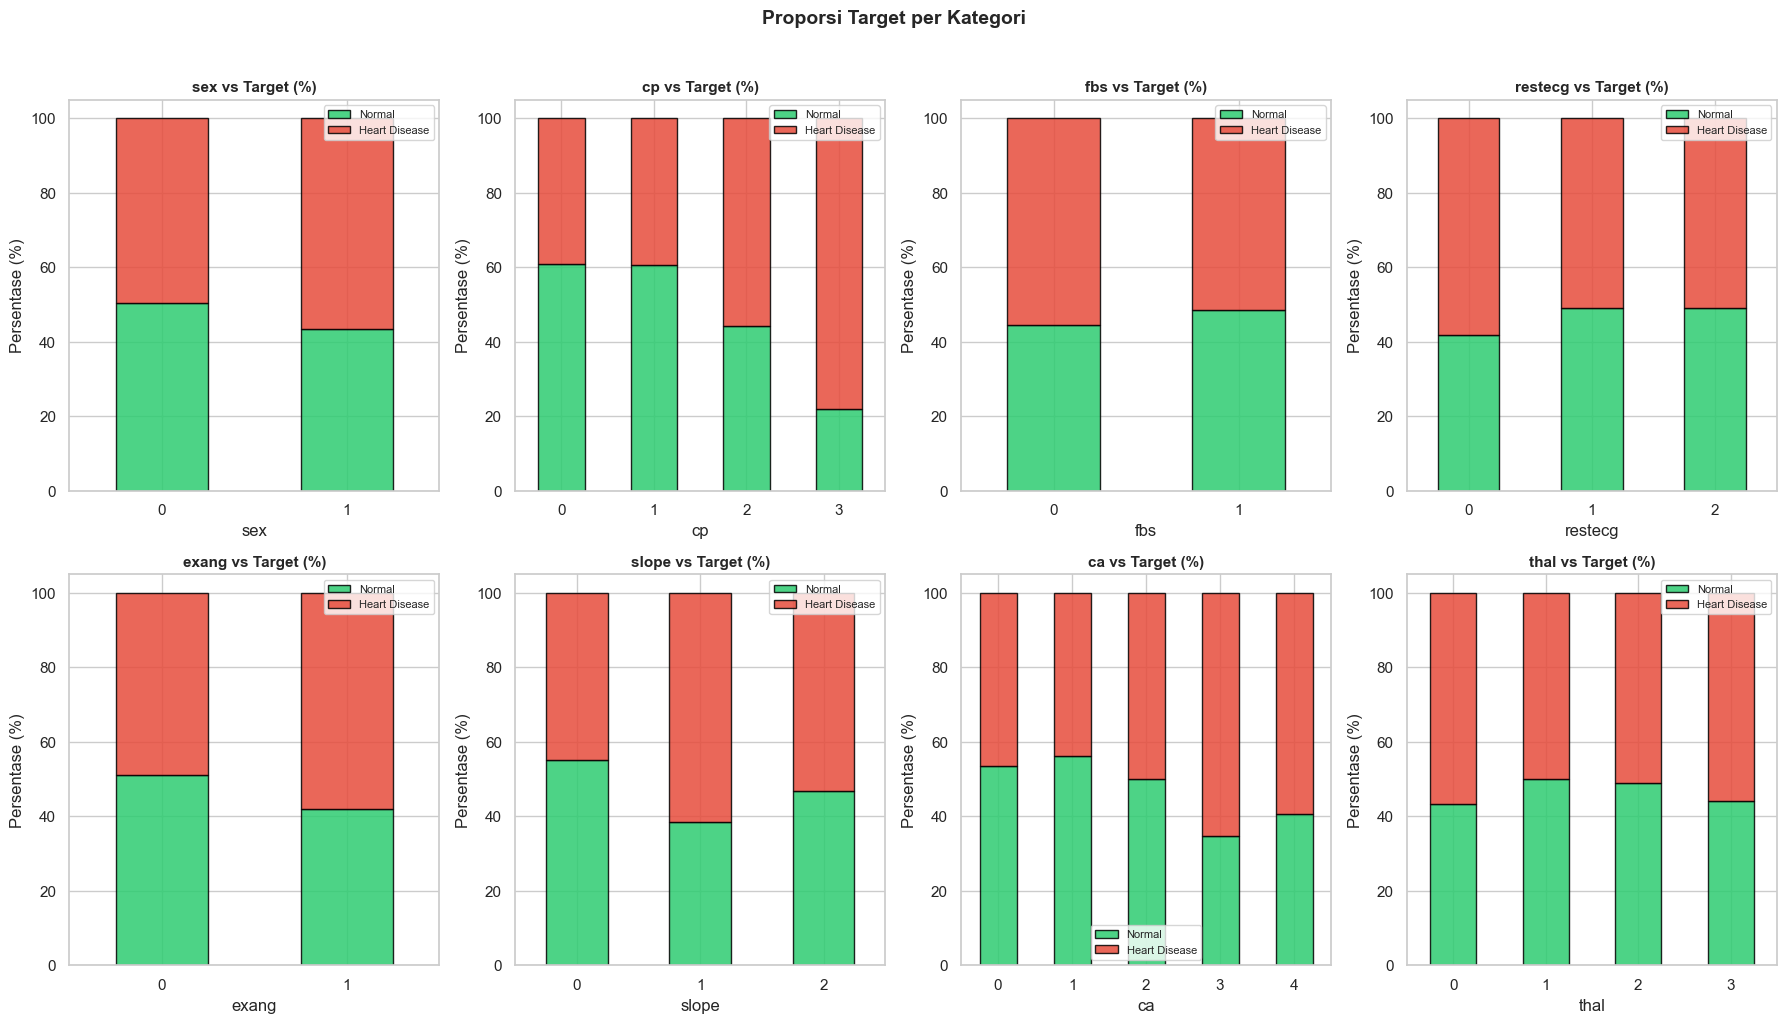

In [14]:
# Analisis variabel kategorikal terhadap target
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], 
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} vs Target (%)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['Normal', 'Heart Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Proporsi Target per Kategori', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pra-pemrosesan data dilakukan untuk mempersiapkan dataset sebelum digunakan dalam pemodelan. Langkah-langkah yang dilakukan meliputi:
1. Penanganan data duplikat.
2. Penanganan nilai kosong.
3. Rekayasa fitur (Feature Engineering) untuk membuat variabel klinis baru.
4. Penerapan One-Hot Encoding pada fitur kategorikal.
5. Pembagian data latih dan uji secara terstrata.
6. Penskalaan standar (Standard Scaling) pada variabel numerik kontinu.
7. Penyimpanan dataset hasil pra-pemrosesan.

### 5.1 Penanganan Data Duplikat

In [15]:
# Hapus baris duplikat
print(f"Dimensi data sebelum: {df.shape}")

df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"Dimensi data setelah menghapus duplikat: {df_clean.shape}")
print(f"Jumlah baris dihapus: {len(df) - len(df_clean)}")
print("Data duplikat berhasil dihapus.")

Dimensi data sebelum: (303, 14)
Dimensi data setelah menghapus duplikat: (300, 14)
Jumlah baris dihapus: 3
Data duplikat berhasil dihapus.


### 5.2 Penanganan Nilai Kosong

In [16]:
# Imputasi nilai kosong menggunakan median
cols_with_missing = ['trestbps', 'chol']

print("Nilai kosong sebelum imputasi:")
print(df_clean[cols_with_missing].isnull().sum())

for col in cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"\n  Kolom '{col}' diisi dengan median = {median_val}")

print("\nTotal nilai kosong setelah imputasi:")
print(df_clean.isnull().sum().sum())

Nilai kosong sebelum imputasi:
trestbps    5
chol        5
dtype: int64

  Kolom 'trestbps' diisi dengan median = 148.0

  Kolom 'chol' diisi dengan median = 353.0

Total nilai kosong setelah imputasi:
0


### 5.3 Rekayasa Fitur (Feature Engineering)

In [17]:
# Pembuatan Fitur Baru
df_feat = df_clean.copy()

# 1. Rasio Kolesterol terhadap Tekanan Darah
df_feat['chol_bps_ratio'] = df_feat['chol'] / (df_feat['trestbps'] + 1e-5)
print("Fitur 'chol_bps_ratio' berhasil dibuat.")
print(f"   Statistik: mean={df_feat['chol_bps_ratio'].mean():.3f}, std={df_feat['chol_bps_ratio'].std():.3f}")

# 2. Pengelompokan Usia
df_feat['age_group'] = pd.cut(df_feat['age'], bins=[0, 45, 60, np.inf], labels=[0, 1, 2]).astype(int)
print("\nFitur 'age_group' berhasil dibuat.")
print(f"   Distribusi: {dict(df_feat['age_group'].value_counts().sort_index())}")

# 3. Rasio Detak Jantung Maksimum terhadap Usia
df_feat['hr_age_ratio'] = df_feat['thalach'] / (df_feat['age'] + 1e-5)
print("\nFitur 'hr_age_ratio' berhasil dibuat.")
print(f"   Statistik: mean={df_feat['hr_age_ratio'].mean():.3f}, std={df_feat['hr_age_ratio'].std():.3f}")

print(f"\nDimensi dataset setelah rekayasa fitur: {df_feat.shape}")
df_feat.head()

Fitur 'chol_bps_ratio' berhasil dibuat.
   Statistik: mean=2.522, std=1.096

Fitur 'age_group' berhasil dibuat.
   Distribusi: {0: np.int64(104), 1: np.int64(90), 2: np.int64(106)}

Fitur 'hr_age_ratio' berhasil dibuat.
   Statistik: mean=2.823, std=1.288

Dimensi dataset setelah rekayasa fitur: (300, 17)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_bps_ratio,age_group,hr_age_ratio
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1,1.394595,2,1.910447
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1,3.696721,1,1.684210
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1,5.047169,0,2.302325
3,71,1,1,139.0,243.0,1,0,74,0,0.7,1,3,0,1,1.748201,2,1.042253
4,36,1,0,128.0,449.0,1,1,169,0,6.0,2,1,2,0,3.507812,0,4.694443


### 5.4 Pembagian Data, Encoding, dan Penskalaan

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur prediktor dan variabel target
X = df_feat.drop(columns=['target'])
y = df_feat['target']

# Kelompokkan jenis kolom
categorical_encode_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group']  # Kategorikal Multi-kelas
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'chol_bps_ratio', 'hr_age_ratio']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_encode_cols, drop_first=True)

# Ubah tipe data dummy boolean ke int
dummy_cols = [col for col in X_encoded.columns if any(mc in col for mc in categorical_encode_cols)]
X_encoded[dummy_cols] = X_encoded[dummy_cols].astype(int)

print(f"Dimensi setelah encoding: {X_encoded.shape}")
print(f"Kolom hasil encoding: {X_encoded.columns.tolist()}")

Dimensi setelah encoding: (300, 23)
Kolom hasil encoding: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'chol_bps_ratio', 'hr_age_ratio', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3', 'age_group_1', 'age_group_2']


In [19]:
# Pembagian data latih (train) dan uji (test) dengan perbandingan 80:20 secara terstrata
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data latih (Train set): {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Jumlah data uji (Test set):   {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nDistribusi target pada data latih: {dict(y_train.value_counts().sort_index())}")
print(f"Distribusi target pada data uji:  {dict(y_test.value_counts().sort_index())}")

Jumlah data latih (Train set): 240 (80.0%)
Jumlah data uji (Test set):   60 (20.0%)

Distribusi target pada data latih: {0: np.int64(113), 1: np.int64(127)}
Distribusi target pada data uji:  {0: np.int64(28), 1: np.int64(32)}


In [20]:
# Standard Scaling pada fitur numerik kontinu
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Gabungkan kembali prediktor dan target
train_preprocessed = X_train_scaled.copy()
train_preprocessed['target'] = y_train

test_preprocessed = X_test_scaled.copy()
test_preprocessed['target'] = y_test

print("Proses penskalaan data selesai.")
print(f"\nDimensi final data latih (Train set): {train_preprocessed.shape}")
print(f"Dimensi final data uji (Test set):   {test_preprocessed.shape}")
print(f"\nVerifikasi penskalaan (mean ≈ 0, std ≈ 1):")
for col in numeric_cols[:3]:
    print(f"  {col}: mean={X_train_scaled[col].mean():.4f}, std={X_train_scaled[col].std():.4f}")

Proses penskalaan data selesai.

Dimensi final data latih (Train set): (240, 24)
Dimensi final data uji (Test set):   (60, 24)

Verifikasi penskalaan (mean ≈ 0, std ≈ 1):
  age: mean=0.0000, std=1.0021
  trestbps: mean=0.0000, std=1.0021
  chol: mean=-0.0000, std=1.0021


### 5.5 Penyimpanan Dataset Hasil Pra-pemrosesan

In [21]:
# Menyimpan dataset hasil pra-pemrosesan
output_dir = 'dataset_preprocessed'
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, 'train.csv')
test_path = os.path.join(output_dir, 'test.csv')

train_preprocessed.to_csv(train_path, index=False)
test_preprocessed.to_csv(test_path, index=False)

print("Dataset pra-pemrosesan berhasil disimpan:")
print(f"   Latih (Train): {train_path} - Dimensi: {train_preprocessed.shape}")
print(f"   Uji (Test):   {test_path} - Dimensi: {test_preprocessed.shape}")
print(f"\nDaftar kolom akhir ({len(train_preprocessed.columns)}):")
for i, col in enumerate(train_preprocessed.columns, 1):
    print(f"   {i:2d}. {col}")

Dataset pra-pemrosesan berhasil disimpan:
   Latih (Train): dataset_preprocessed\train.csv - Dimensi: (240, 24)
   Uji (Test):   dataset_preprocessed\test.csv - Dimensi: (60, 24)

Daftar kolom akhir (24):
    1. age
    2. sex
    3. trestbps
    4. chol
    5. fbs
    6. thalach
    7. exang
    8. oldpeak
    9. ca
   10. chol_bps_ratio
   11. hr_age_ratio
   12. cp_1
   13. cp_2
   14. cp_3
   15. restecg_1
   16. restecg_2
   17. slope_1
   18. slope_2
   19. thal_1
   20. thal_2
   21. thal_3
   22. age_group_1
   23. age_group_2
   24. target


### 5.6 Kesimpulan Eksperimen

#### Ringkasan Dataset
- Jumlah data: 303 sampel dengan 14 variabel awal.
- Variabel target: Diagnosa penyakit jantung (0 = Sehat, 1 = Penyakit Jantung).
- Distribusi kelas: 46.5% normal vs 53.5% penyakit jantung (seimbang).

#### Hasil Analisis dan Pra-pemrosesan
1. Nilai Kosong: Ditemukan nilai kosong pada variabel `trestbps` dan `chol` yang diselesaikan dengan imputasi median.
2. Duplikasi: Sebanyak 3 baris data duplikat telah dihapus.
3. Pencilan: Terdeteksi pencilan pada variabel `trestbps`, `chol`, dan `oldpeak` namun tetap dipertahankan karena mengandung nilai klinis riil.
4. Rekayasa Fitur: Menghasilkan 3 fitur baru yaitu `chol_bps_ratio`, `age_group`, dan `hr_age_ratio`.
5. Penskalaan: Dilakukan Standard Scaling pada seluruh fitur numerik kontinu.
6. Pembagian Data: Data dibagi menjadi 80% untuk data latih dan 20% untuk data uji secara terstrata.

#### Output File
- `dataset_preprocessed/train.csv` (data latih)
- `dataset_preprocessed/test.csv` (data uji)

Dataset yang telah diproses ini siap digunakan untuk tahapan pemodelan selanjutnya.